In [16]:
import scanpy as sc
import pandas as pd
import soupx
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scrublet as scr
from io_utils import save_checkpoint

In [21]:
def detect_doublets(
    adata: sc.AnnData,
    expected_doublet_rate: float | None = None,
    min_counts: int = 2, 
    min_cells: int = 3,
    min_gene_variability_pctl: int = 85,
    n_prin_comps: int = 30,
    use_approx_neighbors: bool = False,
    distance_metric: str = "euclidean"
) -> sc.AnnData:
    """
    -----------
    Parameters
    -----------
        adata: AnnData object. Must contain adata.layers["raw_counts"].
        expected_doublet_rate: Expected doublet rate for this sample. If None, estimate as 0.8% per 1000 recovered cells.
        min_counts: Minimum counts for a gene to be considered by Scrublet.
        min_cells: Minimum number of cells in which a gene must be detected.
        min_gene_variability_pctl: Percentile threshold for selecting variable genes when simulating doublets.
        n_prin_comps: Number of principal components used by Scrublet.
        use_approx_neighbors: Whether to use approximate nearest neighbors in Scrublet. 
        distance_metric: Distance metric used by Scrublet.
    --------
    Returns
    --------
        adata: AnnData object, updated with:
            - adata.obs["doublet_score_scrublet"]
            - adata.obs["predicted_doublet_scrublet"]
    """
    if "raw_counts" not in adata.layers:
        raise KeyError(
            "'raw counts' not found in adata.layers. "
            "Please run freeze_raw_counts() first."
        )
    
    if expected_doublet_rate is None:
        expected_doublet_rate = 0.008 * (adata.n_obs / 1000)
    
    scrub = scr.Scrublet(
        adata.layers["raw_counts"],
        expected_doublet_rate = expected_doublet_rate
    )

    doublet_scores, predicted_doublets = scrub.scrub_doublets(
        min_counts = min_counts,
        min_cells = min_cells,
        min_gene_variability_pctl = min_gene_variability_pctl,
        n_prin_comps = n_prin_comps,
        use_approx_neighbors = use_approx_neighbors,
        distance_metric = distance_metric
    )

    adata.obs["doublet_score_scrublet"] = doublet_scores
    adata.obs["predicted_doublet_scrublet"] = predicted_doublets

    n_cells = adata.n_obs
    n_doublets = int(adata.obs["predicted_doublet_scrublet"].sum())
    predicted_rate = n_doublets / n_cells
    print(
        f"Doublet detection complete.\n"
        f"Cells analysed: {n_cells}\n"
        f"Expected doublet rate used: {expected_doublet_rate:.3%}\n"
        f"Predicted doublets: {n_doublets} ({predicted_rate:.3%})"
    )

    return adata, scrub

In [9]:
def remove_doublets(adata: sc.AnnData) -> sc.AnnData:
    """
    Keep only cells not predicted as doublets.
    -----------
    Parameters
    -----------
        adata: AnnData object alreay annotated by detect_doublets().
    --------
    Returns
    -------- 
        adata_singlets: New AnnData object containing only predicted singlets.
    """

    if "predicted_doublet_scrublet" not in adata.obs.columns:
        raise KeyError(
            "'predicted_doublet_scrublet' not found in adata.obs. " 
            "Please run detect_doublets() first."
        )

    n_before = adata.n_obs
    adata_singlets = adata[~adata.obs["predicted_doublet_scrublet"]].copy()
    n_after = adata_singlets.n_obs
    n_removed = n_before - n_after

    print(
        f"Predicted doublets removes. "
        f"\nCells before: {n_before}, after: {n_after}, removed: {n_removed}."
    )

    return adata_singlets

Below is the C9ALS sample going through the pipeline.

In [22]:
adata_dir = "../data/processed"
adata_als = sc.read_h5ad(f"{adata_dir}/c9ALS_GSM5292146_ambient_rna_removed.h5ad")
adata_als, scrub_als = detect_doublets(adata_als)

Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.25
Detected doublet rate = 4.6%
Estimated detectable doublet fraction = 46.2%
Overall doublet rate:
	Expected   = 7.3%
	Estimated  = 10.0%
Elapsed time: 6.6 seconds
Doublet detection complete.
Cells analysed: 9168
Expected doublet rate used: 7.334%
Predicted doublets: 423 (4.614%)


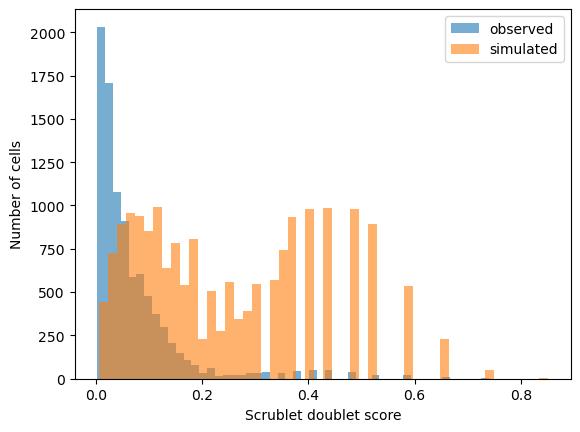

In [23]:
plt.figure()
plt.hist(scrub_als.doublet_scores_obs_, bins=50, alpha=0.6, label="observed")
plt.hist(scrub_als.doublet_scores_sim_, bins=50, alpha=0.6, label="simulated")
plt.xlabel("Scrublet doublet score")
plt.ylabel("Number of cells")
plt.legend()
plt.show()

In [19]:
adata_als_doublets_removed = remove_doublets(adata_als)
save_checkpoint(adata_als_doublets_removed,
                "../data/processed", 
                "doublets_removed") 

Predicted doublets removes. 
Cells before: 9168, after: 8745, removed: 423.
Checkpoint saved: ../data/processed/c9ALS_GSM5292146_doublets_removed.h5ad


PosixPath('../data/processed/c9ALS_GSM5292146_doublets_removed.h5ad')